<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning-with-Pytorch-tutorials/blob/main/02_mnist_classification_using_CNN_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Handwritten digit classification using CNN**

---

![image](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

## **Context**

Previously, we had classified the handwritten digits using Multi Layer Perceptron (MLP) model in this [notebook](https://github.com/harishmuh/Deep-Learning_study/blob/main/01_mnist_classification_using_MLP.ipynb).

In this tutorial, we will also classify handwritten digit, but  using the Convolutional neural network with Pytorch.

**Convolutional Neural Network (CNN)**

A Convolutional Neural Network (CNN) is a type of deep neural network designed primarily for processing grid-structured data such as images. It uses convolutional layers to automatically extract spatial features (e.g., edges, textures, shapes) through local connections and shared weights, making it more efficient than fully connected networks for visual tasks.

**About Handwritten digits - MNIST dataset**

![eight](https://user-images.githubusercontent.com/51207580/59979373-bc052480-9604-11e9-85b8-464367fdc891.png)

Dataset Characteristics:

* 70,000 grayscale images

    * 60,000 training images

    * 10,000 test images

* Image size: 28 × 28 pixels (784 total pixels)

* Pixel range: 0–255

* 10 labels/classes (digits 0–9)

## **Initial setup and Importing library**

In this step, we will importing required libraries, loading dataset, and setting data loaders.

**Importing library**

In [2]:
# Importing required libraries
import torch
import torch.nn as nn                       # Build neural network
import torch.optim as optim                 # Define optimizer
import torchvision.datasets as datasets     # Load dataset
import torchvision.transforms as transforms # Preprocess data
from torch.utils.data import DataLoader     # Multi process data processing, automatic batching, shuffling

# Set random seeds for reproducibility
torch.manual_seed(42)

# Checking PyTorch version
print('PyTorch version:', torch.__version__)

# Defining device manually
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)


PyTorch version: 2.10.0+cu128
Using device: cuda


In [3]:
# Defining hyperparameters for the experiment
num_classes = 10      # Number of output classes
learning_rate = 0.001
batch_size = 100
num_epochs = 10       # Number of iteration - training

**Working with data**

PyTorch has two primitive ways to work as `torch.utils.data.DataLoader` and `torch.utils.data.Dataset`. `Dataset`
stores the samples and their corresponding labels, while `DataLoader`
wraps an iterable around the `Dataset`.

**Loading dataset**

In [4]:
# Loading MNIST dataset and transforming data to tensor format
# Previously the data are on numpy-array for format, we need to transform it to tensor
train_dataset = datasets.MNIST(
    root="data", train=True, transform=transforms.ToTensor(), download=True
) # format:torch.utils.data.Dataset
test_dataset = datasets.MNIST(
    root="data", train=False, transform=transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 517kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.3MB/s]


**Setting data loaders**

In [5]:
# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

=== Batch Information ===
Shape of X [N, C, H, W]: torch.Size([100, 1, 28, 28])
Shape of y: torch.Size([100])
Label data type: torch.int64
First 10 labels: [9, 9, 4, 7, 7, 9, 4, 7, 9, 1]


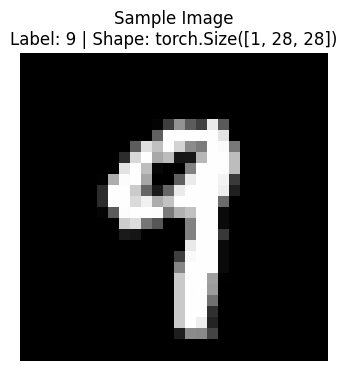

In [7]:
# Displaying sample image and batch information from data loader
import matplotlib.pyplot as plt

# Getting first batch from DataLoader
images, labels = next(iter(train_loader))

# Displaying batch information
print("=== Batch Information ===")
print(f"Shape of X [N, C, H, W]: {images.shape}")
print(f"Shape of y: {labels.shape}")
print(f"Label data type: {labels.dtype}")

# Displaying first 10 labels
print(f"First 10 labels: {labels[:10].tolist()}")

# Showing sample image
plt.figure(figsize=(4, 4))
plt.imshow(images[0].squeeze(), cmap='gray')

# Add image information to title
plt.title(
    f"Sample Image\n"
    f"Label: {labels[1].item()} | "
    f"Shape: {images[1].shape}"
)
plt.axis('off')
plt.show()

## **Model building**

In this step, we will construct CNN model architecture for the experiment.

**Creating models**

To define a neural network in PyTorch, we create a class that inherits from nn.Module. We define the layers of the network in the `__init__` function and specify how data will pass through the network in the `forward` function. To accelerate operations in the neural network, we move it to the accelerator such as CUDA. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

Every time we define a neural network module using PyTorch, we must inherit or make `nn.Module` the parent class.
So that all functions in the `nn.Module class` can be used by its derived classes.

In [8]:
# Defining CNN model architecture
class CNN(nn.Module):
    # How do we extract features
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # Convolution layer: input channel, output_channel, kernel_size, stride, padding
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            # Activation function
            nn.ReLU(),
            # Max pooling layer -> get maximum value
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Convolution layer
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            # Activation function
            nn.ReLU(),
            # Max Pooling layer
            nn.MaxPool2d(kernel_size=2, stride=2),
        ) # Output : B, 32, 7, 7
        self.classifier = nn.Linear(32 * 7 * 7, num_classes)
    # def forward will be processed after we call the nn.Module
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x #B, num_class

# setting the CNN model to the choosen device
model = CNN().to(device)
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=1568, out_features=10, bias=True)
)


**Initializing loss function and optimizer**

Before training a model, we need a `loss function` and `an optimizer`.
* **Loss function/criterion** is a module used to penalize our model and check whether the prediction results are correct
* **Optimizer** is a module used to update the parameters (usually weights) in the model. The value of weights will be upgraded during learning process

In [9]:
# Defining loss function and optimizer

# Defining loss function/criterion
criterion = nn.CrossEntropyLoss()

# Defining optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

**Model training**

In this step, we will set model training parameters. In a single training loop, the model makes predictions on the training dataset (fed to it in batches), and backpropagates the prediction error to adjust the model's parameters.

In [10]:
# Optimizing loop

# Function for model training
def train(model, data_loader, criterion, optimizer, device):

    # We change our model mode into training
    model.train()

    # Variable to store several metrics that will be displayed later during the training process
    total_loss = 0
    correct = 0
    total = 0

    # Iterate data over the data loader, we get images and labels
    for batch_idx, (images, labels) in enumerate(data_loader):

        # We change our image & label to the desired device
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # We delete all gradients stored by the optimizer
        outputs = model(images) # Feedforward process, we predict the input data to the model
        loss = criterion(outputs, labels) # The process of comparing the predicted output with the ground truth or labels
        loss.backward() # The backpropagation process
        optimizer.step() # The process of changing the parameters based on the Backpropagation result

        total_loss += loss.item() # we store the loss value

        # Operation to calculate accuracy
        _, predicted = outputs.max(1) # network output: (B (batch), num_class (output size))
        total += labels.size(0) # we store the total value
        correct += predicted.eq(labels).sum().item() # storing the number of correct values ​​into the correct variable
        # eq: equals, #.item(): to get only the values (not in torch.tensor format)

    return total_loss / len(data_loader), 100.0 * correct / total

**Model evaluation**

In [11]:
# Model evaluation
from sklearn.metrics import precision_score, recall_score, f1_score

# Defining model evaluation
# Similar to previous model training
# but without optimizer (because we don't update weight and bias in this step)
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    predicted_labels = []
    true_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            predicted_labels.extend(predicted.tolist())
            true_labels.extend(labels.tolist())

    # Calculate Precision: TP/(TP+FP)
    precision = precision_score(true_labels, predicted_labels, average="macro")

    # Calculate Recall: TP/(TP+FN)
    recall = recall_score(true_labels, predicted_labels, average="macro")

    # Calculate f1: 2*(Precision*Recall)/Precision+Recall
    f1 = f1_score(true_labels, predicted_labels, average="macro")

    return (
        total_loss / len(data_loader),
        100.0 * correct / total,
        precision,
        recall,
        f1,
        predicted_labels,
        true_labels,
    )

The training process is conducted over several iterations (epochs). Previously we have set the number of epochs as 10. During each epoch, the model learns parameters to make better predictions. We print the model's accuracy and loss at each epoch; we'd like to see the accuracy increase and the loss decrease with every epoch.

In [12]:
# Training loop
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, precision, recall, f1, predicted_labels, true_labels = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, "
        f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}"
    )

Epoch [1/10], Train Loss: 0.3067, Train Acc: 91.31%, Test Loss: 0.0844, Test Acc: 97.21%, Precision: 0.9720, Recall: 0.9720, F1: 0.9719
Epoch [2/10], Train Loss: 0.0822, Train Acc: 97.58%, Test Loss: 0.0600, Test Acc: 98.08%, Precision: 0.9808, Recall: 0.9808, F1: 0.9807
Epoch [3/10], Train Loss: 0.0611, Train Acc: 98.15%, Test Loss: 0.0475, Test Acc: 98.42%, Precision: 0.9843, Recall: 0.9841, F1: 0.9841
Epoch [4/10], Train Loss: 0.0512, Train Acc: 98.44%, Test Loss: 0.0421, Test Acc: 98.60%, Precision: 0.9859, Recall: 0.9859, F1: 0.9859
Epoch [5/10], Train Loss: 0.0432, Train Acc: 98.70%, Test Loss: 0.0435, Test Acc: 98.59%, Precision: 0.9858, Recall: 0.9858, F1: 0.9858
Epoch [6/10], Train Loss: 0.0373, Train Acc: 98.87%, Test Loss: 0.0382, Test Acc: 98.81%, Precision: 0.9882, Recall: 0.9880, F1: 0.9881
Epoch [7/10], Train Loss: 0.0330, Train Acc: 99.00%, Test Loss: 0.0366, Test Acc: 98.80%, Precision: 0.9880, Recall: 0.9879, F1: 0.9879
Epoch [8/10], Train Loss: 0.0288, Train Acc: 99.

In this model evaluation, we get accuracy on the testing dataset as 98.9%. This CNN model has higher accuracy than previous MLP model on this [notebook](https://github.com/harishmuh/Deep-Learning_study/blob/main/01_mnist_classification_using_MLP.ipynb) with accuracy of 97.8%.

**Confusion matrix**

A confusion matrix is a performance measurement tool for machine learning classification models, summarizing how well a model predicts by comparing actual target values with predicted values.

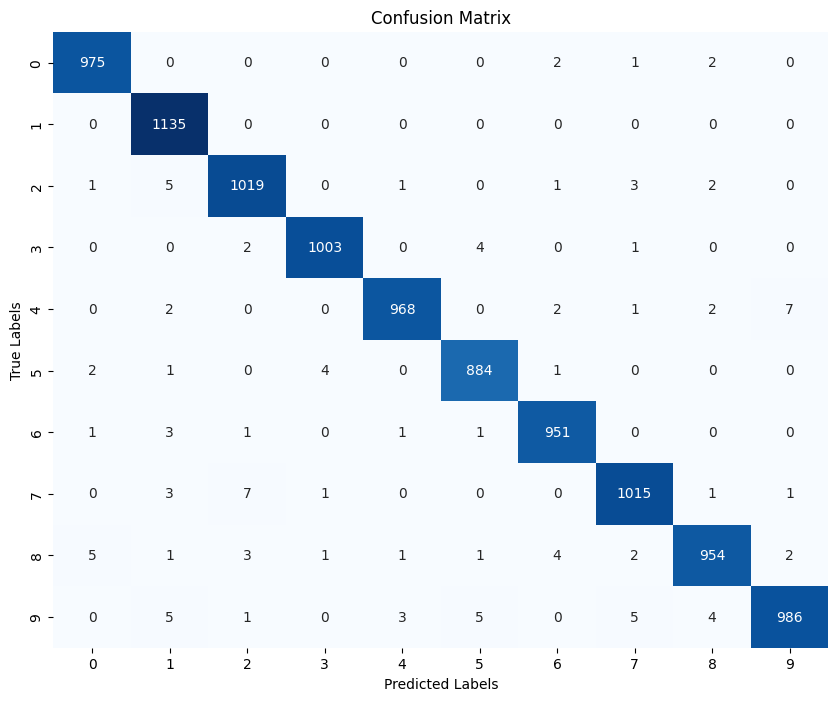

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

### **Simulating prediction**

In this step, we will try to simulate the prediction process using our model.

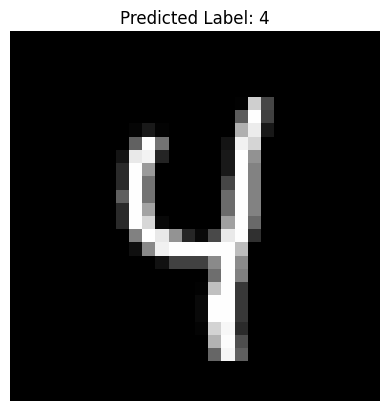

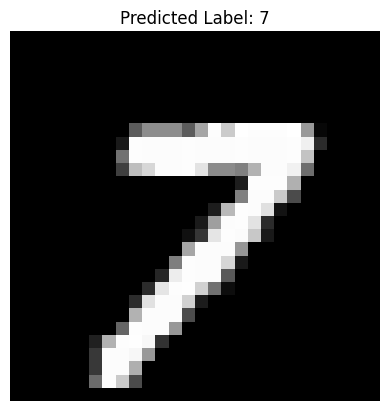

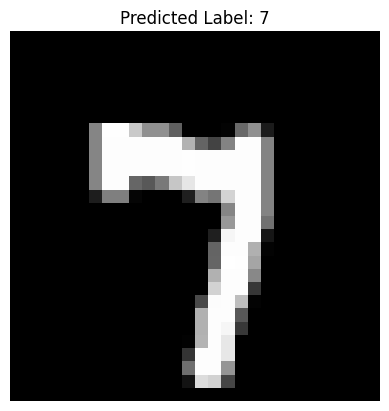

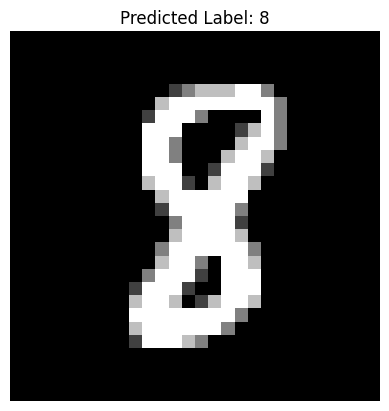

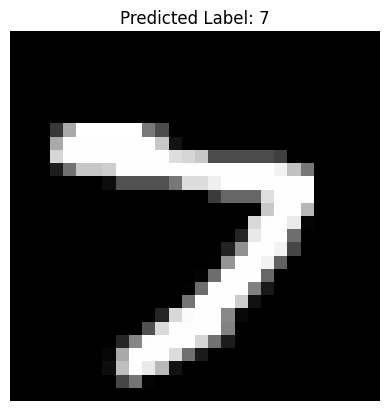

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Function to display the image and predicted label
def show_prediction(image, predicted_label):
    plt.imshow(image.squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"Predicted Label: {predicted_label}")
    plt.show()

# Specify the number of sample images to test
num_samples = 5

# Select random sample images from the test set
sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

for index in sample_indices:
    sample_image, sample_label = test_dataset[index]
    sample_image = sample_image.to(device).unsqueeze(0)

    # Make the prediction
    model.eval()
    with torch.no_grad():
        output = model(sample_image)
        _, predicted = torch.max(output.data, 1)

    # Convert the tensor to a numpy array
    sample_image = sample_image.cpu().squeeze().numpy()

    # Display the sample image and predicted label
    show_prediction(sample_image, predicted.item())

In overall, we can see that the model can make correct prediction for the simulation process.

**Displaying Wrong Predictions**

Now, let's also visualize some of the images that the model misclassified. This can help in understanding where the model might be struggling.

Displaying 5 wrongly predicted images:


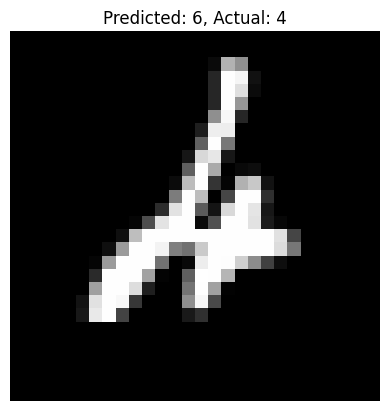

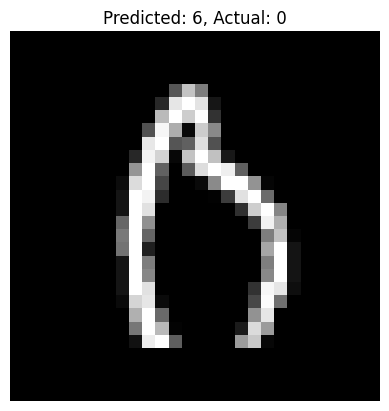

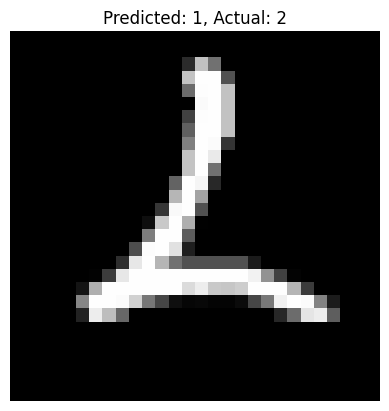

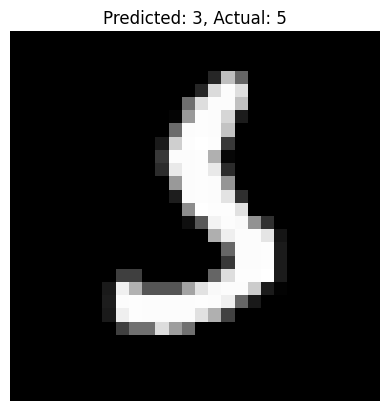

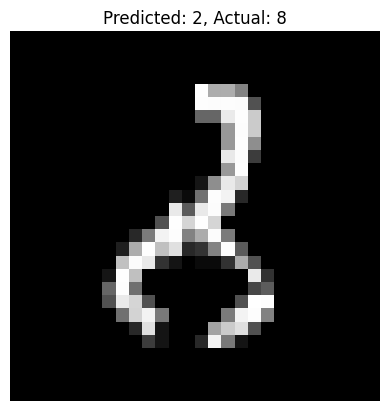

In [15]:
# Displyaing wrong prediction

# setting labels
classes = [str(i) for i in range(10)]

# Find indices of wrongly predicted images
wrong_predictions_indices = [
    i for i, (pred, actual) in enumerate(zip(predicted_labels, true_labels)) if pred != actual
]

# Display a few wrong predictions (e.g., first 5 or fewer if not enough)
num_wrong_to_show = min(5, len(wrong_predictions_indices))

print(f"Displaying {num_wrong_to_show} wrongly predicted images:")
for i in range(num_wrong_to_show):
    index = wrong_predictions_indices[i]
    sample_image, actual_label_idx = test_dataset[index]

    # Prepare image for model prediction
    sample_image_tensor = sample_image.to(device).unsqueeze(0)

    # Make the prediction
    model.eval()
    with torch.no_grad():
        output = model(sample_image_tensor)
        _, predicted_label_idx = torch.max(output.data, 1)

    # Convert tensor to numpy for display
    display_image = sample_image.cpu().squeeze().numpy()
    predicted_label = classes[predicted_label_idx.item()]
    actual_label = classes[actual_label_idx]

    # Display the image with predicted and actual labels
    plt.figure()
    plt.imshow(display_image, cmap="gray")
    plt.axis("off")
    plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}")
    plt.show()

**Saving models**

We can save the model for the future use. A common way to save a model is to serialize the internal state dictionary (containing the model parameters).

In [16]:
# Saving pytorch model
torch.save(model.state_dict(), "CNN_model.pth")
print("Saved PyTorch Model State to CNN_model.pth")

Saved PyTorch Model State to CNN_model.pth


In [18]:
classes = [str(i) for i in range(10)]

model.eval()
x, y = test_dataset[0][0], test_dataset[0][1]
with torch.no_grad():
    x = x.to(device).unsqueeze(0)  # Add batch dimension to the image tensor
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')


Predicted: "7", Actual: "7"


## **Conclusion**

In this notebook, we successfully built and trained a Convolutional Neural Network (CNN) to classify handwritten digits from the MNIST dataset. The model achieved a high test accuracy of **98.90%**, outperforming the previously mentioned MLP model which had an accuracy of 97.8%.


